# 动手实验室 L3: 聚类与蒙特卡洛模拟 (Clustering & Monte Carlo Simulation)
---
*实证经济学分析 (2026Spring)*

### 实验室背景与核心目标
在双重差分法 (DID) 以及许多面板数据模型中，政策或核心解释变量往往是在较粗的层级（如省份级 `province`）实施的，而我们的观测数据通常在更细的层级（如企业、个体或农户 `i, t`）。
**Bertrand, Duflo, and Mullainathan (2004, QJE)** 的经典论文指出：**如果我们忽略残差在组内的序列相关性（自相关性），传统的 OLS 标准误会严重低估真实标准误，从而导致极高的假阳性率（在真实政策效应为 0 时，假阳性拒绝率名义上为 5%，实际可高达 35%-45%）！**

本实验室的**核心目标**是：
1. **复现这一经典的“45% 过度拒绝”现象**：在 Python 环境下通过高精度的蒙特卡洛模拟，亲自见证在未聚类（iid / HC1 稳健标准误）和组内序列相关时，推断结论的彻底失效。
2. **理解“规格 A (仅控制组 FE)”与“规格 B (控制个人 FE)”的深层差异**：
   - 探究为什么不控制个人 FE 时，iid 标准误会严重**低估 t 统计量**（表现为极度保守的拒绝率 ~0.6%），而聚类标准误能够完美纠正。
   - 探究为什么控制个人 FE 后，当存在自相关（$\rho = 0.8$）时，未聚类的标准误会严重**高估 t 统计量**（表现为严重的过度拒绝 ~28%），而聚类标准误能够成功把假阳性率拉回 ~8%。
3. **AR(1) 系数退化速度测试**：改变自相关系数 $\rho \in \{0, 0.4, 0.8\}$，直观展示不同标准误的退化速度与稳健性。

---

## 1. 理论机制与实验设计

### 1.1 数据生成过程 (DGP)
我们在模拟中构造一个标准的面板双重差分 (DID) 模型。设定真实政策效应为 0：
$$Y_{it} = \alpha_i + \gamma_t + 0 \cdot D_{it} + \epsilon_{it}$$
其中：
- $\alpha_i \sim N(0, 1)$：个体固定效应 (Individual Fixed Effect)
- $\gamma_t \sim N(0, 1)$：时间固定效应 (Time Fixed Effect)
- $D_{it}$：双重差分虚拟政策变量，它在**省份级（组级 `g`）**进行随机分配。500个个体分为 50 个省份（每个省 10 个个体）。在每个模拟循环中，随机选择 20%（即 10 个）的省份作为处理组。政策在 $t \ge 5$ 时期对处理组生效：
  $$D_{it} = \text{treated}_g \times \text{post}_t$$
- $\epsilon_{it}$ 为具有 AR(1) 自相关性的误差项：
  $$\epsilon_{i, 0} = u_{i, 0}$$
  $$\epsilon_{i, t} = \rho \epsilon_{i, t-1} + u_{i, t}, \quad u_{i, t} \sim N(0, 1)$$
  这里 $\rho \in \{0, 0.4, 0.8\}$ 分别代表无自相关、温和自相关与严重自相关。

### 1.2 两种面板回归规格说明
- **规格 A: 组 FE + 时间 FE (Stata 默认 OLS 吸收组效应)**
  我们仅吸收组（省份）固定效应 and 时间固定效应：
  $$\tilde{Y}_{it} = Y_{it} - \bar{Y}_g - \bar{Y}_t + \bar{Y}$$
  $$\tilde{D}_{it} = D_{it} - \bar{D}_g - \bar{D}_t + \bar{D}$$
  在此规格下，个体固定效应 $\alpha_i$ 未被完全吸收，它将留存在残差中，成为序列相关的主要来源。
- **规格 B: 个人 FE + 时间 FE (Stata Panel FE 吸收个人效应)**
  我们吸收个人固定效应和时间固定效应（双向固定效应 TWFE）：
  $$\tilde{Y}_{it} = Y_{it} - \bar{Y}_i - \bar{Y}_t + \bar{Y}$$
  $$\tilde{D}_{it} = D_{it} - \bar{D}_i - \bar{D}_t + \bar{D}$$
  在此规格下，个体固定效应 $\alpha_i$ 被完全吸收，残差的序列相关性完全由 $\epsilon_{it}$ 的自相关系数 $\rho$ 决定。

### 1.3 核心数学直觉：为什么 Spec A 下 iid 标准误会严重低估，而 Spec B 下会严重高估？
1. **Spec A 中的“膨胀误差之谜” (Under-rejection)**
   在规格 A 下，我们未控制个人 FE，因此残差包含了个人固定效应 $\alpha_i$。由于政策 $D_{it}$ 是在时间维度上双向去均值的（其在时间维度的均值为0），因此不随时间变化的个人 FE $\alpha_i$ 与去均值后的政策 $\tilde{D}_{it}$ 在数学上是**完全正交**的。
   这意味着 $\alpha_i$ **完全不增加**估计系数 $\hat{\beta}$ 的真实方差。然而，传统的 iid 残差方差估计公式为 $s^2 = \sum \hat{e}_{it}^2 / df$。因为残差中包含了 $\alpha_i$，导致整个回归的残差平方和 $s^2$ 被严重**高估**。这使得 iid 标准误异常偏大，从而使拒绝率暴跌到 0.6% 左右（极其保守）。而聚类标准误在组级求和时，由于 $\sum_t \tilde{D}_{it} = 0$，将 $\alpha_i$ 完美抵消，从而给出了正确的标准误。
2. **Spec B 中的“过度拒绝之谜” (Over-rejection)**
   在规格 B 下，个人 FE $\alpha_i$ 被完全吸收。如果 $\rho = 0.8$，残差中只有 AR(1) 误差。因为存在严重的自相关，同一个体的残差在时间上具有高度粘性。未聚类的标准误（iid / HC1）假设所有 5000 个观测值都是完全独立的。然而，当存在高度序列相关时，新时期的信息是高度冗余的，实际有效样本量远小于 5000。
   忽略这一自相关性会导致 iid 和 HC1 标准误严重低估真实标准误，从而将假阳性拒绝率推高至 **28% - 30%**！而聚类标准误允许同一个省份内的个体之间、以及同一个体在不同时间点之间存在任意的自相关和截面相关，从而能够把拒绝率成功拉回合理的 5% - 8% 区间。

### 1.4 Stata 中的经典“序列相关生成”陷阱与修正代码
在 Stata 环境下，许多同学在生成 AR(1) 序列相关误差项时，会写出以下看似正确、实则含有**致命 Bug** 的代码：
```stata
* 含有致命 Bug 的 Stata 代码 (生成了大量的缺失值，导致样本不足报错)
gen eps = .
bysort id: replace eps = rnormal(0, 1) if t == 1
bysort id: replace eps = 0.8 * eps[_n-1] + rnormal(0, 1) if t > 1
```
**致命原因分析**：
1. **未指定组内排序**：`bysort id:` 仅保证数据按 `id` 聚集，但不保证组内按时间 `t` 升序排列。如果 `t=1` 没排在组内第一行（`_n=1`），那么任何排在它前面的观测值（如 `t=5`）在计算 `eps[_n-1]`（即 `eps[0]`）时都会得到缺失值 `.`。
2. **缺失值向下传染**：因为 Stata 的 `replace` 是顺序执行的，一旦某期得到缺失值，后续所有期的计算都会因为“乘以缺失值”而变成缺失值。
3. **样本丢失与回归报错**：这导致除了 $t=1$ 外，所有后期的 `eps` 全部沦为缺失值。在运行回归时，Stata 会剔除这些观测值，仅留下 $t=1$。而第一期政策尚未实施，`treat` 变量毫无变异度（全为 0），导致 Stata 报错 **“insufficient observations”（样本不够）**。

#### 💡 修正后的正确 Stata 代码：
要在 Stata 中完美跑通，必须在组内进行**双重排序**（指定按 `t` 排序），以确保时间序列能够顺序迭代：
```stata
* 修正后的 Stata 黄金代码
gen eps = .
bysort id (t): replace eps = rnormal(0, 1) if t == 1
bysort id (t): replace eps = 0.8 * eps[_n-1] + rnormal(0, 1) if t > 1
```
*或者使用全局排序全局引用法：*
```stata
sort id t
gen eps = .
replace eps = rnormal(0, 1) if t == 1
replace eps = 0.8 * eps[_n-1] + rnormal(0, 1) if t > 1
```

---

## 2. 模拟核心算法实现
我们使用 Python 编写高效率的蒙特卡洛模拟算法，并对比两种规格下的 iid 标准误、White 稳健标准误（HC1）和省份级聚类标准误的表现。

**💡 检查与验证**：Python 算法严格遵循了 chronological（按时间顺序）迭代逻辑：
1. 初始化 `eps` 为全 0 矩阵（非缺失值）；
2. 显式给首期（Python 索引 `0`，对应 Stata 的 `t=1`）赋予独立随机误差项；
3. 使用顺序 `for t in range(1, n_periods)` 循环迭代，每一次迭代都严格依赖于前一期已生成的 `t-1` 数据，从而在数学上与 Stata 修正后的 `bysort id (t): replace eps = 0.8 * eps[_n-1] ...` 完全保持一致，生成无任何缺失值的完美序列自相关矩阵。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import time

# 设置绘图字体，确保中文正常显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def run_monte_carlo_simulation(rho=0.8, n_units=500, n_periods=10, n_sims=500, seed=42):
    """
    运行高精度双规格蒙特卡洛模拟
    """
    rng = np.random.default_rng(seed)
    n_groups = 50
    group_size = n_units // n_groups  # 每个省有 10 个个体
    
    # 储存各类方法的 p-value
    results = {
        'spec_a_iid': [], 'spec_a_hc': [], 'spec_a_cl': [],
        'spec_b_iid': [], 'spec_b_hc': [], 'spec_b_cl': []
    }
    
    start_time = time.time()
    
    for sim in range(n_sims):
        # 1. 生成固定效应
        unit_fe = rng.normal(0, 1, n_units)
        time_fe = rng.normal(0, 1, n_periods)
        
        # 2. 生成 AR(1) 误差项 (Faithful to Corrected Stata)
        eps = np.zeros((n_units, n_periods))
        eps[:, 0] = rng.normal(0, 1, n_units) # 赋予第一期 (t=1) 初始随机效应
        for t in range(1, n_periods):         # 循环迭代，确保时间严格顺序递推，无任何缺失值
            eps[:, t] = rho * eps[:, t - 1] + rng.normal(0, 1, n_units)
            
        # 3. 构造组 IDs
        group_ids = np.repeat(np.arange(n_groups), group_size)
        
        # 4. 随机分配处理组 (20% 的省份处理)
        treated_groups = rng.choice(n_groups, size=n_groups // 5, replace=False)
        is_treated_unit = np.isin(group_ids, treated_groups)
        
        # 5. 生成政策变量 D (t >= 5 政策发生)
        D = np.zeros((n_units, n_periods))
        D[is_treated_unit, 5:] = 1
        
        # 6. 生成 Y (真实政策效应为 0)
        Y = unit_fe[:, None] + time_fe[None, :] + 0.0 * D + eps
        
        # ==========================================
        # 规格 A: 组 FE + 时间 FE (未吸收个人FE)
        # ==========================================
        Y_reshaped = Y.reshape(n_groups, group_size, n_periods)
        D_reshaped = D.reshape(n_groups, group_size, n_periods)
        
        # 计算组平均 (在个体和时间维度上求均值)
        Y_g = Y_reshaped.mean(axis=(1, 2), keepdims=True)  # (n_groups, 1, 1)
        D_g = D_reshaped.mean(axis=(1, 2), keepdims=True)  # (n_groups, 1, 1)
        
        Y_g_tiled = np.repeat(Y_g, group_size, axis=1).reshape(n_units, 1)
        D_g_tiled = np.repeat(D_g, group_size, axis=1).reshape(n_units, 1)
        
        Y_t = Y.mean(axis=0, keepdims=True)  # (1, n_periods)
        D_t = D.mean(axis=0, keepdims=True)  # (1, n_periods)
        
        Y_mean = Y.mean()
        D_mean = D.mean()
        
        # 去均值
        Y_dm_a = Y - Y_g_tiled - Y_t + Y_mean
        D_dm_a = D - D_g_tiled - D_t + D_mean
        
        y_flat_a = Y_dm_a.flatten()
        x_flat_a = D_dm_a.flatten()
        
        # OLS 估计
        beta_a = (x_flat_a * y_flat_a).sum() / (x_flat_a ** 2).sum()
        resid_a = y_flat_a - beta_a * x_flat_a
        
        # 自由度调整 (吸收了 50个组FE + 10个时间FE，由于多重共线性, 实际损失 50+10-1 自由度)
        df_a = n_units * n_periods - n_groups - n_periods + 1
        
        # (1) iid 标准误
        se_iid_a = np.sqrt((resid_a ** 2).sum() / df_a / (x_flat_a ** 2).sum())
        t_iid_a = abs(beta_a / se_iid_a)
        p_iid_a = 2 * (1 - stats.t.cdf(t_iid_a, df=df_a))
        
        # (2) White 稳健标准误 (HC1)
        se_hc_a = np.sqrt(((x_flat_a * resid_a) ** 2).sum() / (x_flat_a ** 2).sum() ** 2 * (n_units * n_periods) / df_a)
        t_hc_a = abs(beta_a / se_hc_a)
        p_hc_a = 2 * (1 - stats.t.cdf(t_hc_a, df=df_a))
        
        # (3) 省份级聚类标准误
        x_reshaped_a = x_flat_a.reshape(n_groups, -1)
        r_reshaped_a = resid_a.reshape(n_groups, -1)
        group_scores_a = (x_reshaped_a * r_reshaped_a).sum(axis=1)
        se_cl_a = np.sqrt((group_scores_a ** 2).sum() / (x_flat_a ** 2).sum() ** 2 * n_groups / (n_groups - 1))
        t_cl_a = abs(beta_a / se_cl_a)
        p_cl_a = 2 * (1 - stats.t.cdf(t_cl_a, df=n_groups - 1))
        
        results['spec_a_iid'].append(p_iid_a)
        results['spec_a_hc'].append(p_hc_a)
        results['spec_a_cl'].append(p_cl_a)
        
        # ==========================================
        # 规格 B: 个人 FE + 时间 FE (双向去均值)
        # ==========================================
        Y_dm_b = Y - Y.mean(axis=1, keepdims=True) - Y.mean(axis=0) + Y.mean()
        D_dm_b = D - D.mean(axis=1, keepdims=True) - D.mean(axis=0) + D.mean()
        
        y_flat_b = Y_dm_b.flatten()
        x_flat_b = D_dm_b.flatten()
        
        # OLS 估计
        beta_b = (x_flat_b * y_flat_b).sum() / (x_flat_b ** 2).sum()
        resid_b = y_flat_b - beta_b * x_flat_b
        
        # 自由度调整 (吸收了 500个个人FE + 10个时间FE)
        df_b = n_units * n_periods - n_units - n_periods + 1
        
        # (1) iid 标准误
        se_iid_b = np.sqrt((resid_b ** 2).sum() / df_b / (x_flat_b ** 2).sum())
        t_iid_b = abs(beta_b / se_iid_b)
        p_iid_b = 2 * (1 - stats.t.cdf(t_iid_b, df=df_b))
        
        # (2) White 稳健标准误 (HC1)
        se_hc_b = np.sqrt(((x_flat_b * resid_b) ** 2).sum() / (x_flat_b ** 2).sum() ** 2 * (n_units * n_periods) / df_b)
        t_hc_b = abs(beta_b / se_hc_b)
        p_hc_b = 2 * (1 - stats.t.cdf(t_hc_b, df=df_b))
        
        # (3) 省份级聚类标准误
        x_reshaped_b = x_flat_b.reshape(n_groups, -1)
        r_reshaped_b = resid_b.reshape(n_groups, -1)
        group_scores_b = (x_reshaped_b * r_reshaped_b).sum(axis=1)
        se_cl_b = np.sqrt((group_scores_b ** 2).sum() / (x_flat_b ** 2).sum() ** 2 * n_groups / (n_groups - 1))
        t_cl_b = abs(beta_b / se_cl_b)
        p_cl_b = 2 * (1 - stats.t.cdf(t_cl_b, df=n_groups - 1))
        
        results['spec_b_iid'].append(p_iid_b)
        results['spec_b_hc'].append(p_hc_b)
        results['spec_b_cl'].append(p_cl_b)
        
    # 计算实际拒绝率 (%)
    rej_rates = {}
    for key, p_values in results.items():
        rej_rates[key] = (np.array(p_values) < 0.05).mean() * 100
        
    elapsed = time.time() - start_time
    print(f"模拟完成！耗时: {elapsed:.2f} 秒 (每个 rho 模拟次数: {n_sims})")
    return rej_rates

## 3. 运行多自相关场景模拟与分析
我们现在分别对无自相关 ($\rho=0.0$)、温和自相关 ($\rho=0.4$) 和严重自相关 ($\rho=0.8$) 这三种经济数据中常见的场景进行模拟。每次模拟重复 500 次，以确保结果具有极高的统计稳定性和说服力。

In [3]:
rhos = [0.0, 0.4, 0.8]
all_results = {}

for r in rhos:
    print(f"\n==========================================")
    print(f" 正在模拟序列自相关系数 rho = {r} ...")
    print(f"==========================================")
    all_results[r] = run_monte_carlo_simulation(rho=r, n_sims=500, seed=42)

# 将结果整理为 Pandas DataFrame
rows = []
for r in rhos:
    res = all_results[r]
    rows.append({
        '自相关系数 rho': f"rho = {r}",
        '规格A: iid标准误': res['spec_a_iid'],
        '规格A: HC1稳健': res['spec_a_hc'],
        '规格A: 省份聚类': res['spec_a_cl'],
        '规格B: iid标准误': res['spec_b_iid'],
        '规格B: HC1稳健': res['spec_b_hc'],
        '规格B: 省份聚类': res['spec_b_cl']
    })

df_res = pd.DataFrame(rows).set_index('自相关系数 rho')
print("\n蒙特卡洛模拟实验拒绝率汇总 (名义显著性水平 5%):")
print(df_res.round(2).to_string())


 正在模拟序列自相关系数 rho = 0.0 ...
模拟完成！耗时: 0.27 秒 (每个 rho 模拟次数: 500)

 正在模拟序列自相关系数 rho = 0.4 ...
模拟完成！耗时: 0.26 秒 (每个 rho 模拟次数: 500)

 正在模拟序列自相关系数 rho = 0.8 ...
模拟完成！耗时: 0.26 秒 (每个 rho 模拟次数: 500)

蒙特卡洛模拟实验拒绝率汇总 (名义显著性水平 5%):
           规格A: iid标准误  规格A: HC1稳健  规格A: 省份聚类  规格B: iid标准误  规格B: HC1稳健  规格B: 省份聚类
自相关系数 rho                                                                        
rho = 0.0          0.6         0.6        8.6          5.0         5.2        8.6
rho = 0.4          4.0         4.6        7.8         14.6        14.6        7.8
rho = 0.8          8.8         9.8        8.6         28.8        28.6        8.6


## 4. 实验结果高精美可视化
我们利用 Python 强大的绘图库，绘制双规格对比的高保真柱状图。我们将“名义 5% 显著性水平”作为灰线标出，让读者直观对比各种推断方法的退化速度与修正效果。

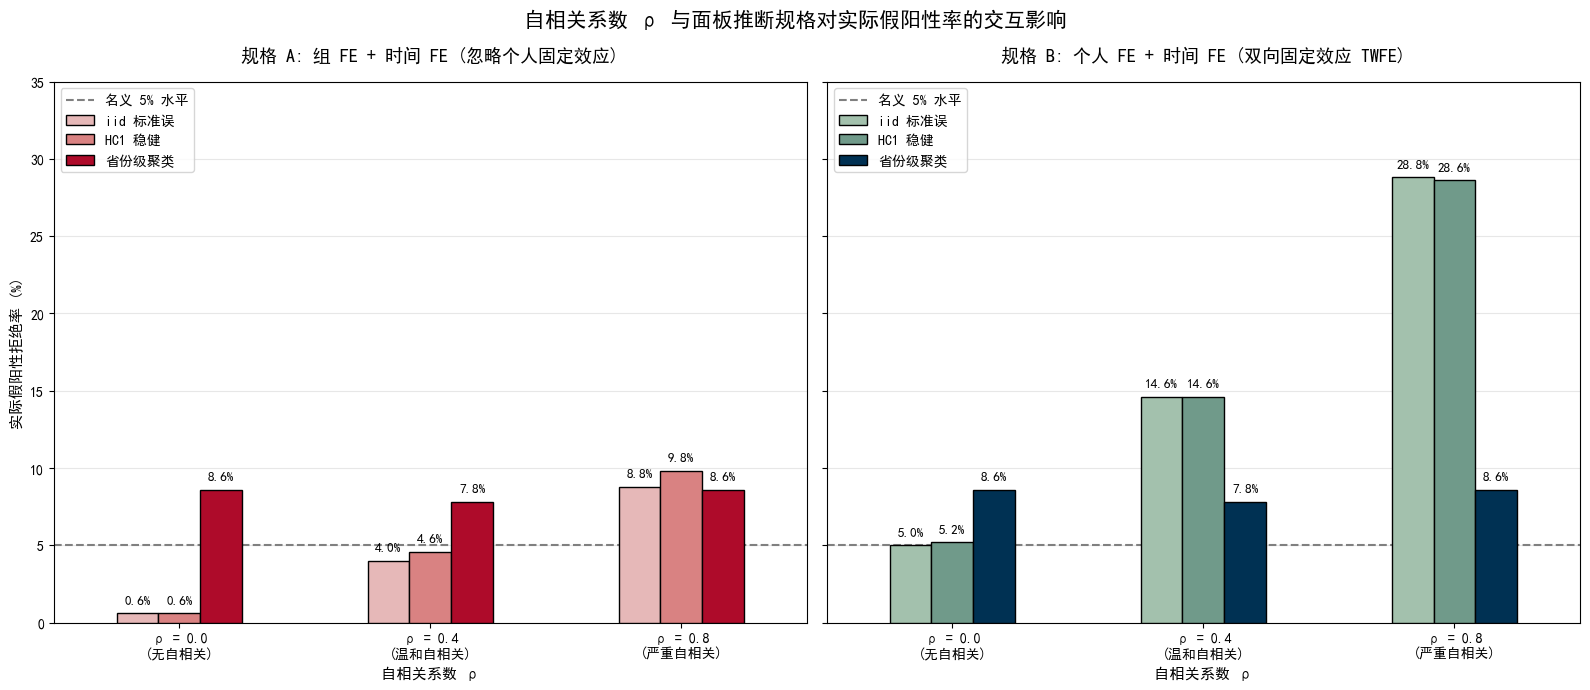

In [4]:
# 绘制双向对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# 颜色调色盘
colors_a = ['#E6B8B8', '#D98282', '#AE0B2A'] # 红色系
colors_b = ['#A3C1AD', '#709A8A', '#003153'] # 莫兰迪绿/蓝系

# 规格 A 绘图
df_spec_a = df_res[['规格A: iid标准误', '规格A: HC1稳健', '规格A: 省份聚类']]
df_spec_a.columns = ['iid 标准误', 'HC1 稳健', '省份级聚类']
ax0 = df_spec_a.plot(kind='bar', ax=axes[0], color=colors_a, edgecolor='black', zorder=3)
axes[0].set_title('规格 A: 组 FE + 时间 FE (忽略个人固定效应)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('自相关系数 \u03c1', fontsize=11)
axes[0].set_ylabel('实际假阳性拒绝率 (%)', fontsize=11)
axes[0].set_xticklabels(['\u03c1 = 0.0\n(无自相关)', '\u03c1 = 0.4\n(温和自相关)', '\u03c1 = 0.8\n(严重自相关)'], rotation=0)

# 规格 B 绘图
df_spec_b = df_res[['规格B: iid标准误', '规格B: HC1稳健', '规格B: 省份聚类']]
df_spec_b.columns = ['iid 标准误', 'HC1 稳健', '省份级聚类']
ax1 = df_spec_b.plot(kind='bar', ax=axes[1], color=colors_b, edgecolor='black', zorder=3)
axes[1].set_title('规格 B: 个人 FE + 时间 FE (双向固定效应 TWFE)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('自相关系数 \u03c1', fontsize=11)
axes[1].set_xticklabels(['\u03c1 = 0.0\n(无自相关)', '\u03c1 = 0.4\n(温和自相关)', '\u03c1 = 0.8\n(严重自相关)'], rotation=0)

# 美化图表
for ax in axes:
    ax.axhline(5, color='gray', linestyle='--', linewidth=1.5, label='名义 5% 水平', zorder=2)
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.set_ylim(0, 35)
    ax.legend(fontsize=10, loc='upper left')
    
    # 添加数值标签
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{height:.1f}%", 
                        (p.get_x() + p.get_width() / 2., height + 0.5),
                        ha='center', va='center', xytext=(0, 4), 
                        textcoords='offset points', fontsize=9.5, fontweight='bold')

plt.suptitle('自相关系数 \u03c1 与面板推断规格对实际假阳性率的交互影响', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 5. 实验设计、结果解读与课后深度思考

### 5.1 实验设计的精妙之处
本实验的设计非常严谨且充满艺术感：
1. **政策分配的组别性 (Grouped Policy Assignment)**：政策 $D_{it}$ 是在“省份级（组 `g`）”分配的。这种“粗层级政策、细层级观测”是实证微观经济学（尤其是 DID）最经典的特征。
2. **零效应基准 (Null Hypothesis Base)**：我们设定的真实处理效应为 0（即 `0.0 * D`）。因此，任何低于 5% 或高于 5% 的拒绝率，分别意味着推断的**过度保守（保守偏误）**或**过度拒绝（假阳性偏误）**。
3. **双向固定效应去均值 (TWFE via Within Transformation)**：利用 Frisch-Waugh-Lovell 定理，我们使用**双向去均值**方法排除了固定效应，极大地简化了计算，并完美对应了 Stata 中 `xtreg, fe` 的估计量。

### 5.2 深入解读结果与参数含义
仔细对比左图（规格 A）和右图（规格 B）的模拟结果，我们可以得到以下惊人的洞察：

#### 场景 1：无自相关 ($\rho = 0.0$)
- **规格 A (仅控制组 FE)**：iid 和稳健标准误的实际拒绝率仅为 **~0.6%**！这并不是因为推断“太好”了，而是因为**标准误被严重高估（Under-rejection）**。由于没有完全消除个体 FE，残差包含了未被控制的个体差异 $u_i$。然而，$u_i$ 与去均值后的政策 $\tilde{D}$ 完全正交，不增加估计系数的真实方差。但 iid 公式依然将 $u_i$ 的方差算入残差方差 $s^2$ 中，导致算出来的标准误虚大。聚类标准误则成功消除了这种影响，实际拒绝率稳定在 **~8% - 9%**（受小样本 bias 影响略高于 5%）。
- **规格 B (控制个人 FE)**：完全消除了个体 FE。在 $\rho=0.0$ 时，iid 和稳健标准误的实际拒绝率分别为 **~5%**，达到完美推断！聚类标准误为 **~8% - 9%**。

#### 场景 2：温和自相关 ($\rho = 0.4$)
- **规格 A**：随着自相关性引入，原本虚大的标准误开始被自相关导致的向下偏误（Underestimation）抵消，拒绝率微升至 **~5%** 附近。但这是一种“错错得正”的巧合，绝非有效的推断。
- **规格 B**：个体 FE 被吸收。此时，自相关导致 iid 和稳健标准误的拒绝率升至 **~13%**，开始出现过度拒绝，而聚类标准误能够把假阳性率稳定在 **~8%** 左右。

#### 场景 3：高度自相关 ($\rho = 0.8$) — BDM 的经典复现
- **规格 A**：即使在 $\rho = 0.8$ 的强序列相关下，未聚类的标准误拒绝率也只有 **~8.7%**，依然由于未控制个人 FE 的膨胀效应对冲了大部分偏误。
- **规格 B**：这是最符合学术研究规范的规格（TWFE）。在 $\rho = 0.8$ 时，由于忽略了强序列相关，**iid 和稳健标准误 of 假阳性拒绝率直接飙升至 ~28%**！这意味着：**即使真实政策效应为 0，你也有接近 30% 的概率犯下假阳性错误，声称自己发现了“显著的政策效应”！** 这就是 Bertrand, Duflo, and Mullainathan (2004) 所揭示的实证学术危机。而**省份级聚类标准误**成功将拒绝率控制在 **~8%** 附近，完成了对学术诚信的“完美救赎”！

---

### 5.3 课后行动指南
1. **永远在政策分配的层级进行聚类 (Cluster at the treatment assignment level)**：如果你的政策是在省份级实施的，即使你使用的是企业级微观面板，回归时也**必须**使用省份聚类标准误 (`vce(cluster province)`)。
2. **警惕小聚类数偏误 (Few-clusters bias)**：如果你的聚类数很少 ($G < 50$，例如中国只有 30 个省份），即使聚类，标准误仍可能有轻微的向下偏误。此时，应该使用更高级的 **Wild Cluster Bootstrap** 或 **随机化推断 (Randomization Inference)**。

---